## What This Deck Demonstrates

- One notebook, two outputs: a working `.ipynb` **and** a shareable slide deck
- Render command: `quarto render home-credit-eda-slides.ipynb --to revealjs`
- Content below mirrors the shape of the Home Credit Default Risk EDA (synthetic data here, swap in the real dataframe later)

## Simulating the Dataset

In [ ]:
#| echo: false
#| output: true      # show the output (default is true anyway)
#| warning: false     # suppress warning messages
#| fig-cap: "My chart"  # caption if it's a plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
n = 2000

df = pd.DataFrame({
    "SK_ID_CURR": np.arange(100001, 100001 + n),
    "TARGET": rng.choice([0, 1], size=n, p=[0.92, 0.08]),
    "AMT_INCOME_TOTAL": rng.gamma(shape=5, scale=30000, size=n).round(0),
    "AMT_CREDIT": rng.gamma(shape=6, scale=90000, size=n).round(0),
    "DAYS_BIRTH": -rng.integers(7500, 25000, size=n),
    "DAYS_EMPLOYED": -rng.integers(0, 15000, size=n),
    "NAME_EDUCATION_TYPE": rng.choice(
        ["Secondary", "Higher education", "Incomplete higher", "Lower secondary"],
        size=n, p=[0.55, 0.30, 0.10, 0.05]
    ),
})

# inject some realistic missingness
for col, rate in [("AMT_INCOME_TOTAL", 0.02), ("DAYS_EMPLOYED", 0.18), ("NAME_EDUCATION_TYPE", 0.01)]:
    mask = rng.random(n) < rate
    df.loc[mask, col] = np.nan

df.head()

,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,DAYS_BIRTH,DAYS_EMPLOYED,NAME_EDUCATION_TYPE
0,100001,0,83546.0,488190.0,-19237,-10861.0,Secondary
1,100002,0,75626.0,647449.0,-16574,-2130.0,Secondary
2,100003,0,105351.0,631921.0,-11125,NaN,Secondary
3,100004,0,102459.0,459466.0,-23614,-10243.0,Higher education
4,100005,0,125248.0,240318.0,-20896,-7712.0,Secondary


## Target Class Imbalance

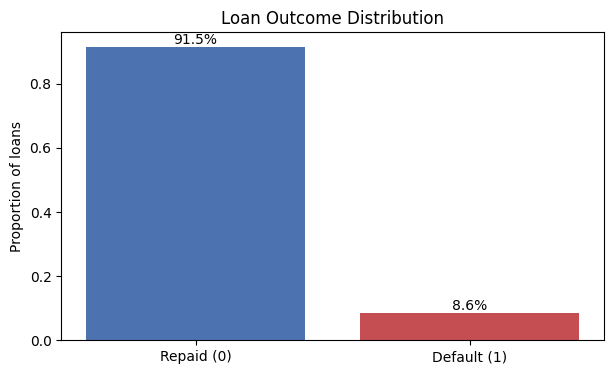

In [2]:
#| echo: false
#| fig-cap: "TARGET is heavily imbalanced — roughly 8% default"

counts = df["TARGET"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["Repaid (0)", "Default (1)"], counts.values, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Proportion of loans")
ax.set_title("Loan Outcome Distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.show()

## Missingness Snapshot

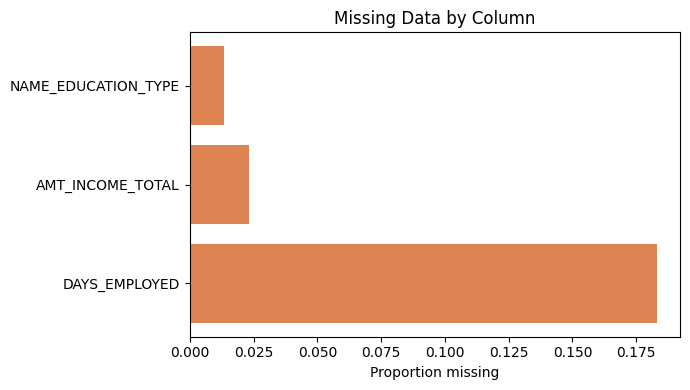

In [3]:
#| echo: false
#| fig-cap: "Percent missing by column"

missing_pct = df.isna().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(missing_pct.index, missing_pct.values, color="#DD8452")
ax.set_xlabel("Proportion missing")
ax.set_title("Missing Data by Column")
plt.tight_layout()
plt.show()

## Income vs. Default Rate

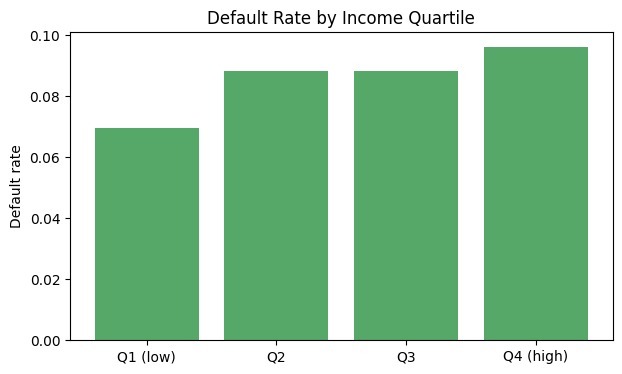

In [4]:
#| echo: false
#| fig-cap: "Default rate by income quartile — a domain-driven feature idea"

df["income_quartile"] = pd.qcut(df["AMT_INCOME_TOTAL"], 4, labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])
default_by_income = df.groupby("income_quartile", observed=True)["TARGET"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(default_by_income.index.astype(str), default_by_income.values, color="#55A868")
ax.set_ylabel("Default rate")
ax.set_title("Default Rate by Income Quartile")
plt.show()

## How This Becomes Slides

- Every `##` heading starts a new slide
- `#| echo: false` in a code cell hides the code, keeps the output
- `#| fig-cap: "..."` adds a caption under a plot
- `embed-resources: true` bundles everything into one portable `.html` file — easy to host on GitHub Pages or link from a portfolio

## Next Steps

- Swap synthetic `df` for the real Home Credit dataframe
- Pull in `python_style_util.py` for consistent colours/fonts across plots
- Add speaker notes with `::: {.notes}` blocks
- Push the rendered `.html` to GitHub Pages and link it from the portfolio